# Reasoning Depth: Model Comparison

Compare depth 0/1/2 against baselines (joe, random, blind_L0, blind_L1) using:
1. Correlation grids with participant judgments (Logan moral + Joe universalizability)
2. Beta / ΔR² regression metrics
3. Internal simulation correlations (mean time, last time, UAW)
4. Support for partial depth2 data (common-map subset)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

from build_utils import (
    get_experimental_data, get_outcome_metrics,
    get_universalization_summary, build_design_matrix,
)
from comparison_utils import (
    evaluate_runs, plot_two_panel, plot_single_panel, plot_comparison_table,
)

%matplotlib inline
Path("figures").mkdir(exist_ok=True)


## 1. Load participant data

In [2]:
XP_FILE = "country_agg_judgment.csv"
COUNTRY = None

xp = get_experimental_data(XP_FILE)
out = get_outcome_metrics(recompute=False)

# Joe's US data
try:
    joe_xp = pd.read_csv("../data/experimental/joe_agg_univ_and_moral_judgments.csv")
    print(f"Joe's data: {len(joe_xp)} stimuli")
except FileNotFoundError:
    joe_xp = None
    print("Joe's data not found (optional)")


Joe's data: 28 stimuli


## 2. Define runs

In [3]:
# ── Main runs: the 4 models we emphasize ──
# Two versions of L0, two versions of L1
MAIN_RUNS = {
    "blind_L0":       "blind_L0_random_02-06",    # old true L0 (random, blind, no prediction)
    "blind_L1":       "blind_l1_random_02-06",     # old L1 heuristic (predecessors only)
    "depth0":         "depth0_03-16",              # new L0 (should match blind_L0)
    "depth1":         "depth1_03-16",              # new depth 1 (predicts all others)
    "depth2":         "depth2_03-16",              
    "depth0_v2":         "v2_d0_03-21",              # 
    "depth1_v2":         "v2_d1_03-21",              # TO UNCONMENT
    "depth2_v2":         "v2_d2_03-21",              
}

# ── Other baselines ──
OTHER_RUNS = {
    "joe":            "joe_1_02-06",               # Joe's original (fixed, full, L0)
    "random_full":    "full_random_02-06",          # random order, full info
}

ALL_RUNS = {**MAIN_RUNS, **OTHER_RUNS}
print("Runs configured:")
for tag, d in ALL_RUNS.items():
    print(f"  {tag:15s} → {d}")


Runs configured:
  blind_L0        → blind_L0_random_02-06
  blind_L1        → blind_l1_random_02-06
  depth0          → depth0_03-16
  depth1          → depth1_03-16
  depth2          → depth2_03-16
  depth0_v2       → v2_d0_03-21
  depth1_v2       → v2_d1_03-21
  depth2_v2       → v2_d2_03-21
  joe             → joe_1_02-06
  random_full     → full_random_02-06


## 3. Build universalization summaries & design matrices

In [4]:
univ_summaries = {}
design_mats = {}

for tag, run_label in ALL_RUNS.items():
    try:
        univ = get_universalization_summary(run_label, recompute=False) # Turn to true to build new summaries
        univ_summaries[tag] = univ
        design = build_design_matrix(univ, out, xp, country=COUNTRY)
        design_mats[tag] = design
    except Exception as e:
        print(f"  {tag} ({run_label}): {e}")

print(f"\nLoaded {len(design_mats)} / {len(ALL_RUNS)} runs")

# Joe DV merge
dm_joe = {}
if joe_xp is not None:
    for tag, dm in design_mats.items():
        merged = dm.copy()
        merged["_mk"] = merged["stimulus"].str.replace(r"_(1cut|bad|badder)$", "", regex=True)
        joe_r = joe_xp.rename(columns={"stimulus": "_mk"})
        merged = merged.merge(
            joe_r[["_mk", "univ_judgment_mean", "moral_judgment_mean"]],
            on="_mk", how="left"
        ).drop(columns=["_mk"])
        dm_joe[tag] = merged



Loaded 10 / 10 runs


## 4. Correlation grid: simulations × participant judgments

Pearson r between each model's U_AW and participant judgments (+ cross-model correlations).


In [28]:
def make_combined_corr_table(design_mats, dm_joe, xp_df,
                             uaw_col="univ_aggregate_welfare",
                             country_col="country",
                             us_label="United States",
                             save_path=None):
    """
    Single correlation matrix: DVs (Logan moral, Logan US, Joe univ, Joe moral)
    × all models' U_AW, plus cross-model correlations.
    """
    # --- Base: Logan moral (all countries) ---
    base = (xp_df[["stimulus", "judgment_mean"]]
            .drop_duplicates(subset=["stimulus"]).copy())
    combined = base.copy()

    # --- Logan US-only ---
    if country_col in xp_df.columns:
        xp_us = xp_df[xp_df[country_col] == us_label]
        if len(xp_us) > 0:
            base_us = (xp_us[["stimulus", "judgment_mean"]]
                       .drop_duplicates(subset=["stimulus"])
                       .rename(columns={"judgment_mean": "judgment_mean_us"}))
            combined = combined.merge(base_us, on="stimulus", how="left")

    # --- Model U_AW columns ---
    for tag, dm in design_mats.items():
        sub = dm[["stimulus", uaw_col]].rename(columns={uaw_col: f"U_AW_{tag}"})
        combined = combined.merge(sub, on="stimulus", how="inner")

    # --- Joe DVs ---
    if dm_joe:
        first_dm = dm_joe[list(dm_joe.keys())[0]]
        joe_cols = [c for c in ["univ_judgment_mean", "moral_judgment_mean"]
                    if c in first_dm.columns]
        if joe_cols:
            joe_sub = first_dm[["stimulus"] + joe_cols].drop_duplicates(subset=["stimulus"])
            combined = combined.merge(joe_sub, on="stimulus", how="left")

    # --- Assemble column lists ---
    dv_cols = ["judgment_mean"]
    dv_labels = {"judgment_mean": "Logan moral (all)"}

    if "judgment_mean_us" in combined.columns:
        dv_cols.append("judgment_mean_us")
        dv_labels["judgment_mean_us"] = "Logan moral (US)"

    if "univ_judgment_mean" in combined.columns:
        dv_cols.append("univ_judgment_mean")
        dv_labels["univ_judgment_mean"] = "Joe univ."

    if "moral_judgment_mean" in combined.columns:
        dv_cols.append("moral_judgment_mean")
        dv_labels["moral_judgment_mean"] = "Joe moral"

    uaw_cols = [c for c in combined.columns if c.startswith("U_AW_")]
    tags = [c.replace("U_AW_", "") for c in uaw_cols]

    all_cols = dv_cols + uaw_cols
    all_labels = list(dv_labels.values()) + tags

    # --- Correlation matrix ---
    corr = combined[all_cols].corr()
    corr.columns = all_labels
    corr.index = all_labels

    # --- Enforce display order ---
    display_order = (
        ["Logan moral (all)", "Logan moral (US)", "Joe univ.", "Joe moral"] +
        ["blind_L0", "blind_L1"] +
        ["depth0", "depth1", "depth2"] +
        ["depth0_v2", "depth1_v2", "depth2_v2"]
    )
    display_order = [c for c in display_order if c in corr.columns]
    corr = corr.loc[display_order, display_order]

    # --- Style ---
    styled = (corr.round(3).style
              .background_gradient(cmap="RdYlGn", vmin=0.0, vmax=1.0)
              .format("{:.3f}", na_rep="—"))

    # --- Save ---
    if save_path:
        corr.round(4).to_csv(save_path)
        print(f"Saved to {save_path}")

# --- Style with separators ---
    n_dvs = len([c for c in display_order if c in list(dv_labels.values())])
    n_baselines = len([c for c in display_order if c in ["blind_L0", "blind_L1"]])
    n_v1 = len([c for c in display_order if c in ["depth0", "depth1", "depth2"]])
    
    # Build border CSS for separator columns
    borders = {}
    sep_positions = []
    pos = 0
    for group_size in [n_dvs, n_baselines, n_v1]:  # last group (v2) needs no right border
        pos += group_size
        if pos < len(display_order):
            sep_positions.append(pos - 1)
    
    def add_borders(styler):
        styles = []
        for col_idx in sep_positions:
            col_name = display_order[col_idx]
            styles.append({
                "selector": f"th:nth-child({col_idx + 2}), td:nth-child({col_idx + 2})",
                "props": [("border-right", "3px solid black")]
            })
        for row_idx in sep_positions:
            row_name = display_order[row_idx]
            styles.append({
                "selector": f"tr:nth-child({row_idx + 1}) td, tr:nth-child({row_idx + 1}) th",
                "props": [("border-bottom", "3px solid black")]
            })
        return styler.set_table_styles(styles, overwrite=False)
    
    styled = (corr.round(3).style
              .background_gradient(cmap="RdYlGn", vmin=0.0, vmax=1.0)
              .format("{:.3f}", na_rep="—")
              .pipe(add_borders))
    return corr, styled


# --- Run it ---
# Check what the country column is called
print("Columns in xp:", list(xp.columns))
if "country" in xp.columns:
    print("Countries:", sorted(xp["country"].unique()))
elif "Country" in xp.columns:
    print("Countries:", sorted(xp["Country"].unique()))


Columns in xp: ['country', 'stimulus', 'judgment_mean', 'judgment_stdev', 'sample_size']
Countries: ['Brazil', 'Canada', 'Egypt', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Israel', 'Italy', 'Japan', 'Portugal', 'South Africa', 'Spain', 'Sweden', 'Turkey', 'Ukraine', 'United Kingdom', 'United States', 'Vietnam']


In [29]:
summary_corr, styled_corr = make_combined_corr_table(
    design_mats, dm_joe, xp,
    save_path="figures/correlation_table_all_models.csv"
)
display(styled_corr)

Saved to figures/correlation_table_all_models.csv


,Logan moral (all),Logan moral (US),Joe univ.,Joe moral,blind_L0,blind_L1,depth0,depth1,depth2,depth0_v2,depth1_v2,depth2_v2
Logan moral (all),1.000,0.816,0.460,0.484,0.155,0.473,0.155,0.446,0.497,0.339,0.260,0.460
Logan moral (US),0.816,1.000,0.609,0.636,0.231,0.563,0.231,0.545,0.515,0.501,0.295,0.527
Joe univ.,0.460,0.609,1.000,0.935,0.429,0.821,0.429,0.816,0.842,0.849,0.754,0.756
Joe moral,0.484,0.636,0.935,1.000,0.210,0.778,0.210,0.737,0.687,0.798,0.674,0.568
blind_L0,0.155,0.231,0.429,0.210,1.000,0.601,1.000,0.659,0.684,0.552,0.776,0.608
blind_L1,0.473,0.563,0.821,0.778,0.601,1.000,0.601,0.713,0.813,0.950,0.763,0.686
depth0,0.155,0.231,0.429,0.210,1.000,0.601,1.000,0.659,0.684,0.552,0.776,0.608
depth1,0.446,0.545,0.816,0.737,0.659,0.713,0.659,1.000,0.849,0.629,0.597,0.591
depth2,0.497,0.515,0.842,0.687,0.684,0.813,0.684,0.849,1.000,0.714,0.760,0.756
depth0_v2,0.339,0.501,0.849,0.798,0.552,0.950,0.552,0.629,0.714,1.000,0.706,0.648


## 5. Regression: beta & ΔR²

Beta on U_AW in `judgment ~ outcome_vars + U_AW`, and ΔR² from adding U_AW.


In [26]:
def plot_grouped_metrics(eval_df, metric="delta_R2",
                        ylabel=None, title=None, save_path=None,
                        figsize=(12, 5)):
    """
    Grouped bar plot with models colored by category.
    
    Categories:
    - Baselines (gray): blind_L0, blind_L1
    - v1 blind (blue): depth0, depth1, depth2
    - v2 obs. model (orange): depth0_v2, depth1_v2, depth2_v2
    - Other (light gray): joe, random_full
    """
    categories = [
        ("Baselines",       ["blind_L0", "blind_L1"],               "#78909C"),
        ("v1 (blind)",      ["depth0", "depth1", "depth2"],         "#42A5F5"),
        ("v2 (obs. model)", ["depth0_v2", "depth1_v2", "depth2_v2"], "#FF8A65"),
        ("Other",           ["joe", "random_full"],                  "#BDBDBD"),
    ]

    if ylabel is None:
        ylabel = metric
    if title is None:
        title = f"{metric} by model"

    fig, ax = plt.subplots(figsize=figsize)

    x_pos = 0
    x_ticks = []
    x_labels = []
    legend_handles = []

    for cat_name, cat_models, color in categories:
        present = [m for m in cat_models if m in eval_df["tag"].values]
        if not present:
            continue

        group_start = x_pos
        for model in present:
            row = eval_df[eval_df["tag"] == model].iloc[0]
            val = row[metric]

            bar = ax.bar(x_pos, val, color=color, alpha=0.85,
                         edgecolor="white", linewidth=0.5, width=0.8)

            # CI error bars for beta
            if metric == "beta_U_AW":
                ci_lo = row.get("ci_lo_U_AW", np.nan)
                ci_hi = row.get("ci_hi_U_AW", np.nan)
                if pd.notna(ci_lo) and pd.notna(ci_hi):
                    ax.errorbar(x_pos, val,
                                yerr=[[val - ci_lo], [ci_hi - val]],
                                fmt="none", color="black", capsize=3, linewidth=1)

            # Significance star
            p = row.get("p_U_AW", 1.0)
            if pd.notna(p) and p < 0.05:
                offset = max(val, 0) + 0.003
                ax.text(x_pos, offset, "*", ha="center", fontsize=12, fontweight="bold")

            x_ticks.append(x_pos)
            x_labels.append(model)
            x_pos += 1

        x_pos += 0.7  # gap between groups

        # Legend entry
        import matplotlib.patches as mpatches
        legend_handles.append(mpatches.Patch(color=color, alpha=0.85, label=cat_name))

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        fig.savefig(save_path.replace(".png", ".pdf"), bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()
    return fig


=== Logan cross-cultural moral judgments ===



,tag,r_U_AW,beta_U_AW,se_U_AW,p_U_AW,delta_R2,delta_BIC
0,blind_L1,0.5890,0.1100,0.0364,0.0048,0.0792,-5.5907
1,joe,0.5470,0.1022,0.0354,0.0067,0.0739,-4.9050
2,random_full,0.5957,0.1057,0.0373,0.0077,0.0715,-4.5944
3,depth0_v2,0.5050,0.0803,0.0303,0.0121,0.0642,-3.6638
4,depth2_v2,0.5482,0.0573,0.0230,0.0176,0.0580,-2.8934
5,depth2,0.6073,0.0413,0.0357,0.2556,0.0142,2.1593
6,depth1_v2,0.3516,0.0381,0.0333,0.2607,0.0139,2.1910
7,depth1,0.5860,0.0104,0.0324,0.7500,0.0011,3.5454
8,blind_L0,0.2333,0.0012,0.0200,0.9515,0.0000,3.6593
9,depth0,0.2333,0.0012,0.0200,0.9515,0.0000,3.6593


Saved to figures/depth_delta_r2_grouped.png


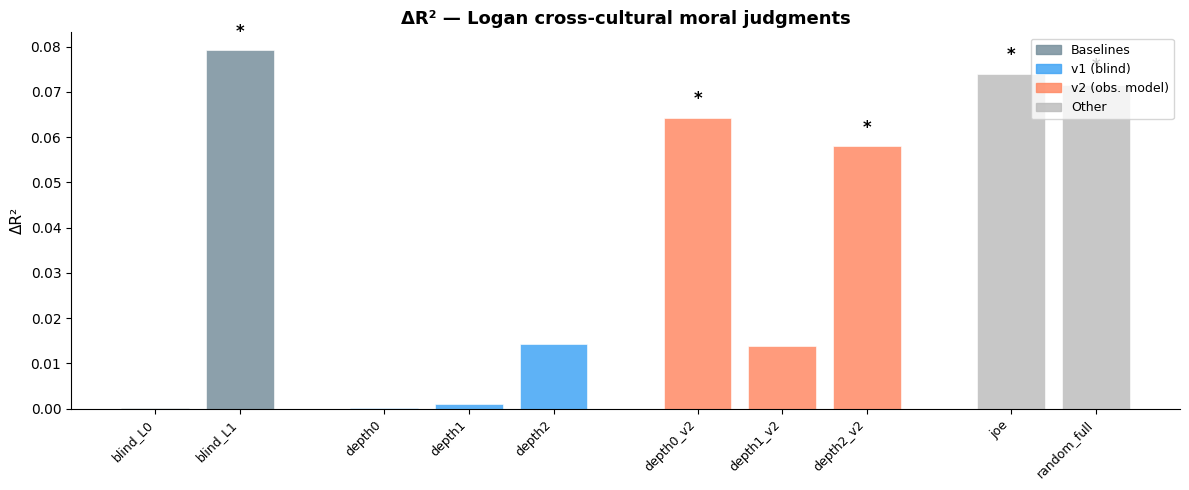

Saved to figures/depth_beta_grouped.png


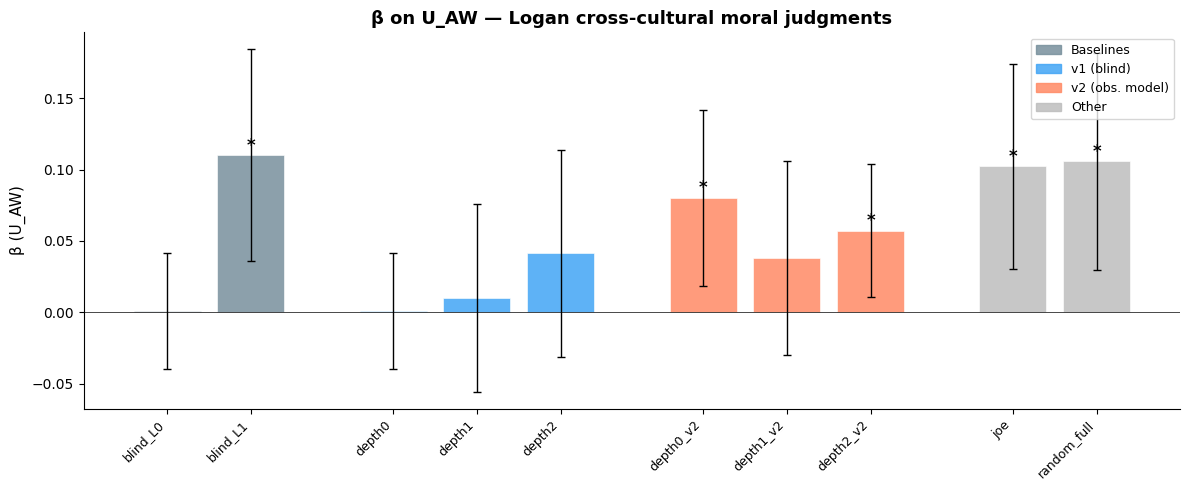

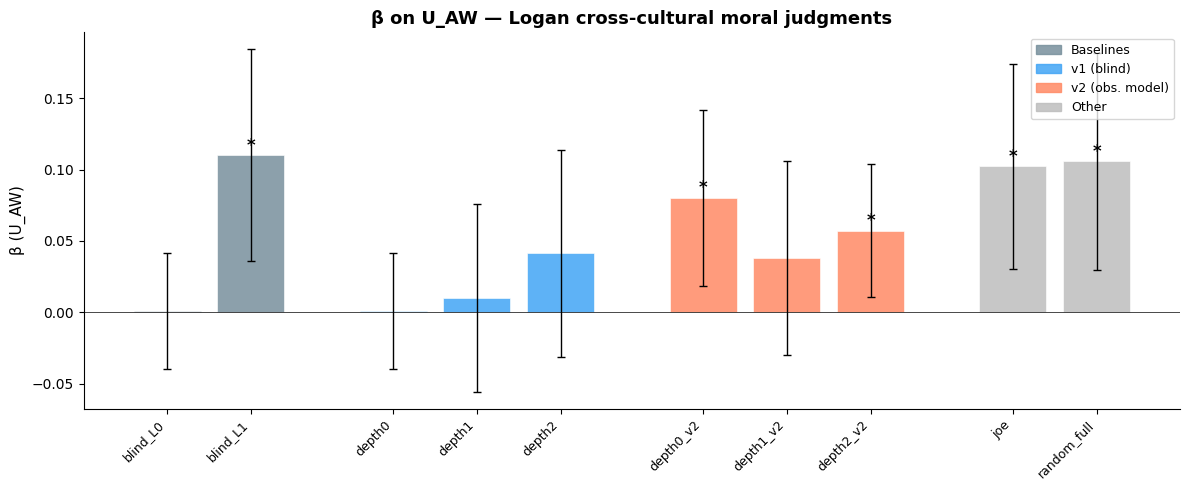

In [27]:
print("=== Logan cross-cultural moral judgments ===\n")
eval_logan = evaluate_runs(design_mats)
eval_logan = eval_logan.sort_values("delta_R2", ascending=False)
display(eval_logan[["tag", "r_U_AW", "beta_U_AW", "se_U_AW", "p_U_AW",
                     "delta_R2", "delta_BIC"]].round(4))
eval_logan.round(4).to_csv("figures/eval_logan_all_models.csv", index=False)

plot_grouped_metrics(eval_logan, metric="delta_R2",
                     ylabel="ΔR²",
                     title="ΔR² — Logan cross-cultural moral judgments",
                     save_path="figures/depth_delta_r2_grouped.png")

plot_grouped_metrics(eval_logan, metric="beta_U_AW",
                     ylabel="β (U_AW)",
                     title="β on U_AW — Logan cross-cultural moral judgments",
                     save_path="figures/depth_beta_grouped.png")


=== Joe universalizability judgments ===



,tag,r_U_AW,beta_U_AW,se_U_AW,p_U_AW,delta_R2
0,depth2,0.8424,7.0177,1.1935,0.0004,0.5857
1,depth2_v2,0.7563,4.7736,0.9828,0.0013,0.5386
2,depth0_v2,0.8489,4.6892,1.1555,0.0036,0.4854
3,depth1,0.8156,6.6130,1.7096,0.0048,0.4700
4,joe,0.8334,5.7231,1.4973,0.0051,0.4660
5,random_full,0.8218,5.8932,1.5752,0.0057,0.4589
6,blind_L1,0.8213,5.6936,1.5427,0.0061,0.4544
7,depth1_v2,0.7545,6.5965,1.9189,0.0089,0.4301
8,blind_L0,0.4295,2.2298,1.0231,0.0609,0.2687
9,depth0,0.4295,2.2298,1.0231,0.0609,0.2687


Saved to figures/depth_delta_r2_joe_grouped.png


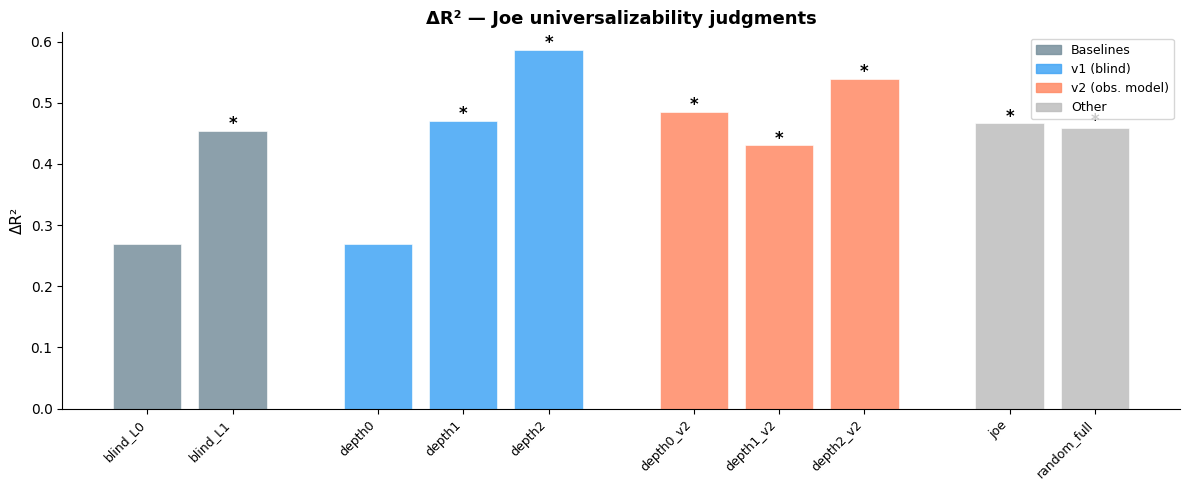

Saved to figures/depth_beta_joe_grouped.png


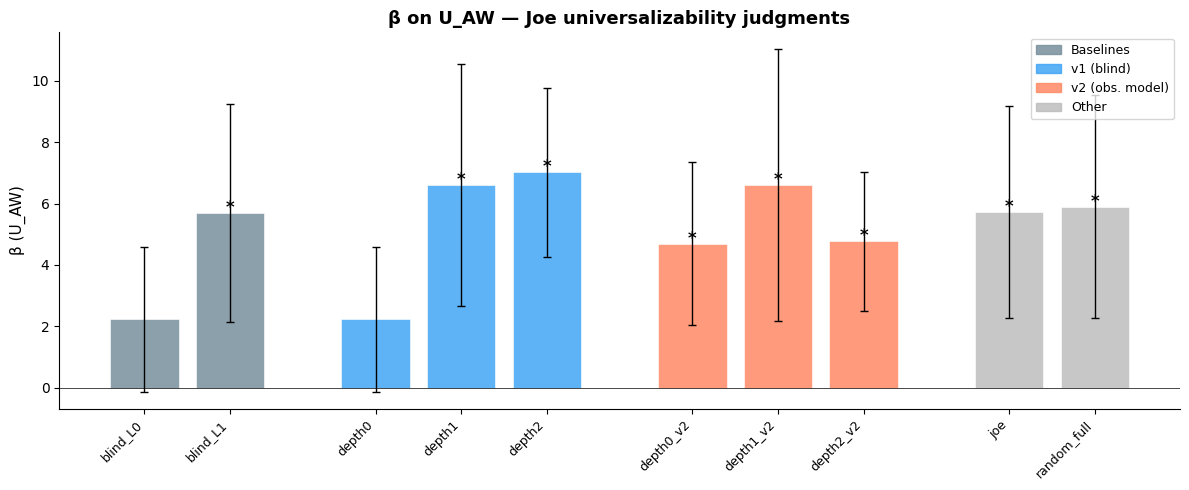

In [25]:
if dm_joe:
    print("=== Joe universalizability judgments ===\n")
    eval_joe = evaluate_runs(dm_joe, dv_col="univ_judgment_mean")
    eval_joe = eval_joe.sort_values("delta_R2", ascending=False)
    display(eval_joe[["tag", "r_U_AW", "beta_U_AW", "se_U_AW", "p_U_AW",
                       "delta_R2"]].round(4))
    eval_joe.round(4).to_csv("figures/eval_joe_all_models.csv", index=False)

    plot_grouped_metrics(eval_joe, metric="delta_R2",
                         ylabel="ΔR²",
                         title="ΔR² — Joe universalizability judgments",
                         save_path="figures/depth_delta_r2_joe_grouped.png")

    plot_grouped_metrics(eval_joe, metric="beta_U_AW",
                         ylabel="β (U_AW)",
                         title="β on U_AW — Joe universalizability judgments",
                         save_path="figures/depth_beta_joe_grouped.png")


## 6. Internal correlations: simulation metrics

How much do models agree on simulation outputs (not participant data)?
Metrics: mean completion time, last agent time, aggregate welfare.


In [45]:
def make_sim_corr_grid(univ_summaries, metric="mean"):
    """Correlate a simulation metric across all models on common maps."""
    tags = list(univ_summaries.keys())
    
    combined = univ_summaries[tags[0]][["map", metric]].rename(
        columns={metric: tags[0]})
    for tag in tags[1:]:
        sub = univ_summaries[tag][["map", metric]].rename(columns={metric: tag})
        combined = combined.merge(sub, on="map", how="inner")
    
    n_maps = len(combined)
    corr = combined[tags].corr()
    
    styled = (corr.round(3).style
              .background_gradient(cmap="RdYlGn", vmin=0.8, vmax=1.0)
              .format("{:.3f}"))
    
    return corr, styled, n_maps

for metric_name, metric_label in [("mean", "Mean completion time"), 
                                   ("last", "Last agent time"),
                                   ("univ_aggregate_welfare", "Universalized AW")]:
    try:
        corr, styled, n = make_sim_corr_grid(univ_summaries, metric=metric_name)
        print(f"\n=== {metric_label} ({n} common maps) ===")
        display(styled)
    except Exception as e:
        print(f"  {metric_label}: {e}")



=== Mean completion time (28 common maps) ===


,blind_L0,blind_L1,depth0,depth1,depth2,depth0_v2,depth2_v2,joe,random_full
blind_L0,1.000,0.763,1.000,0.819,0.835,0.704,0.695,0.739,0.774
blind_L1,0.763,1.000,0.763,0.810,0.915,0.975,0.819,0.994,0.998
depth0,1.000,0.763,1.000,0.819,0.835,0.704,0.695,0.739,0.774
depth1,0.819,0.810,0.819,1.000,0.915,0.744,0.699,0.772,0.822
depth2,0.835,0.915,0.835,0.915,1.000,0.843,0.817,0.882,0.924
depth0_v2,0.704,0.975,0.704,0.744,0.843,1.000,0.772,0.987,0.970
depth2_v2,0.695,0.819,0.695,0.699,0.817,0.772,1.000,0.796,0.817
joe,0.739,0.994,0.739,0.772,0.882,0.987,0.796,1.000,0.993
random_full,0.774,0.998,0.774,0.822,0.924,0.970,0.817,0.993,1.000



=== Last agent time (28 common maps) ===


,blind_L0,blind_L1,depth0,depth1,depth2,depth0_v2,depth2_v2,joe,random_full
blind_L0,1.000,0.628,1.000,0.667,0.752,0.581,0.522,0.626,0.648
blind_L1,0.628,1.000,0.628,0.777,0.781,0.985,0.711,0.997,0.992
depth0,1.000,0.628,1.000,0.667,0.752,0.581,0.522,0.626,0.648
depth1,0.667,0.777,0.667,1.000,0.921,0.732,0.667,0.761,0.807
depth2,0.752,0.781,0.752,0.921,1.000,0.721,0.759,0.762,0.813
depth0_v2,0.581,0.985,0.581,0.732,0.721,1.000,0.668,0.985,0.966
depth2_v2,0.522,0.711,0.522,0.667,0.759,0.668,1.000,0.700,0.723
joe,0.626,0.997,0.626,0.761,0.762,0.985,0.700,1.000,0.991
random_full,0.648,0.992,0.648,0.807,0.813,0.966,0.723,0.991,1.000



=== Universalized AW (28 common maps) ===


,blind_L0,blind_L1,depth0,depth1,depth2,depth0_v2,depth2_v2,joe,random_full
blind_L0,1.000,0.641,1.000,0.676,0.764,0.603,0.629,0.620,0.651
blind_L1,0.641,1.000,0.641,0.705,0.844,0.963,0.683,0.986,0.994
depth0,1.000,0.641,1.000,0.676,0.764,0.603,0.629,0.620,0.651
depth1,0.676,0.705,0.676,1.000,0.858,0.648,0.563,0.651,0.723
depth2,0.764,0.844,0.764,0.858,1.000,0.773,0.736,0.799,0.857
depth0_v2,0.603,0.963,0.603,0.648,0.773,1.000,0.654,0.976,0.959
depth2_v2,0.629,0.683,0.629,0.563,0.736,0.654,1.000,0.662,0.686
joe,0.620,0.986,0.620,0.651,0.799,0.976,0.662,1.000,0.987
random_full,0.651,0.994,0.651,0.723,0.857,0.959,0.686,0.987,1.000


## 7. Per-map scatter: where do models diverge?

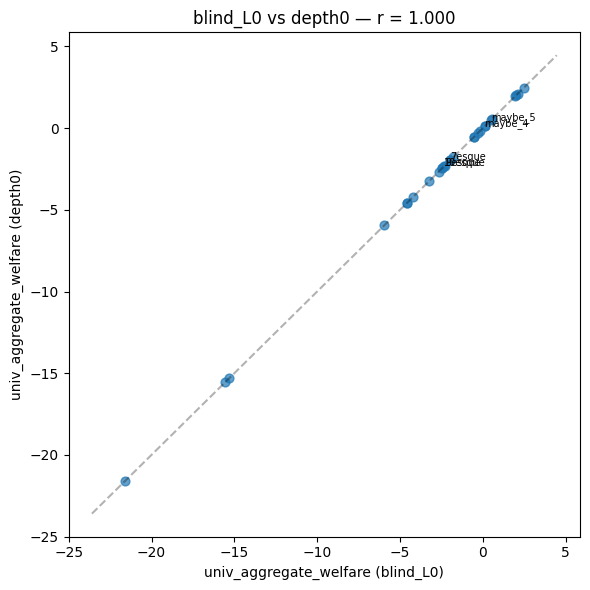

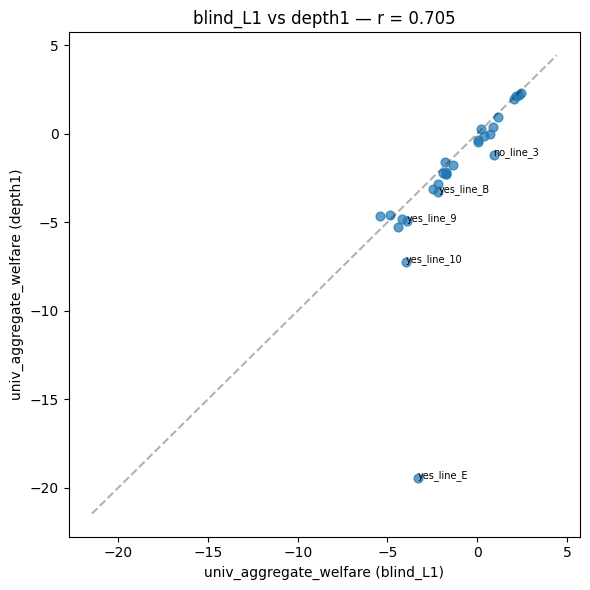

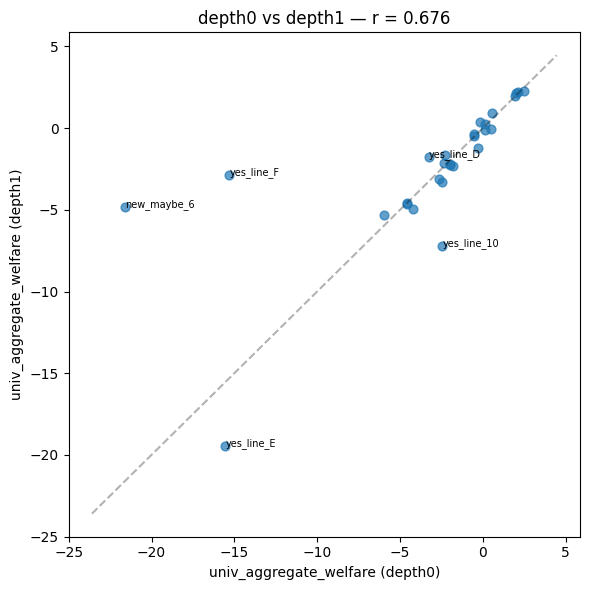

In [46]:
def scatter_two_models(univ_summaries, tag_x, tag_y, 
                       metric="univ_aggregate_welfare", n_label=5):
    """Scatter plot of one metric for two models."""
    dx = univ_summaries[tag_x].set_index("map")[[metric]]
    dy = univ_summaries[tag_y].set_index("map")[[metric]]
    common = dx.index.intersection(dy.index)
    
    df = pd.DataFrame({tag_x: dx.loc[common, metric].values,
                       tag_y: dy.loc[common, metric].values}, index=common)
    r = df.corr().iloc[0, 1]
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df[tag_x], df[tag_y], s=40, alpha=0.7)
    lims = [df.min().min() - 2, df.max().max() + 2]
    ax.plot(lims, lims, "k--", alpha=0.3)
    
    df["diff"] = (df[tag_y] - df[tag_x]).abs()
    for stim in df.nlargest(n_label, "diff").index:
        ax.annotate(stim, (df.loc[stim, tag_x], df.loc[stim, tag_y]), fontsize=7)
    
    ax.set_xlabel(f"{metric} ({tag_x})")
    ax.set_ylabel(f"{metric} ({tag_y})")
    ax.set_title(f"{tag_x} vs {tag_y} — r = {r:.3f}")
    plt.tight_layout()
    return fig

# Key comparisons
pairs = [
    ("blind_L0", "depth0"),      # should be ~identical (both L0)
    ("blind_L1", "depth1"),      # old L1 vs new depth1
    ("depth0", "depth1"),        # L0 vs depth1
]

for tx, ty in pairs:
    if tx in univ_summaries and ty in univ_summaries:
        fig = scatter_two_models(univ_summaries, tx, ty)
        fig.savefig(f"figures/{tx}_vs_{ty}_scatter.png", dpi=150, bbox_inches="tight")
        plt.show()


## 8. Summary: ΔR² bar chart

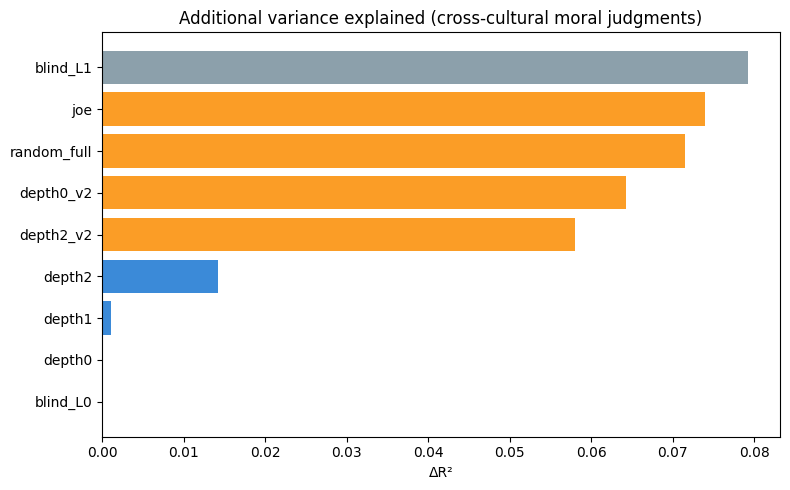

In [47]:
if len(eval_logan) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df = eval_logan.sort_values("delta_R2", ascending=True)
    
    colors = []
    for tag in plot_df["tag"]:
        if tag in ["depth0", "depth1", "depth2"]:
            colors.append("#1976D2")
        elif tag in ["blind_L0", "blind_L1"]:
            colors.append("#78909C")
        else:
            colors.append("#FB8C00")
    
    ax.barh(range(len(plot_df)), plot_df["delta_R2"], color=colors, alpha=0.85)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["tag"])
    ax.set_xlabel("ΔR²")
    ax.set_title("Additional variance explained (cross-cultural moral judgments)")
    plt.tight_layout()
    plt.savefig("figures/depth_delta_r2_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
